# Cookie Cats A/B Test Analysis
### Did moving the first gate from level 30 to level 40 affect player retention?

**Dataset:** [Cookie Cats Kaggle dataset](https://www.kaggle.com/datasets/yufengsui/mobile-games-ab-testing). 90,189 players randomly assigned to `gate_30` (control) or `gate_40` (treatment) at install. Outcomes are `retention_1`, `retention_7`, and `sum_gamerounds` over 14 days.

**Goal:** figure out whether moving the gate changed 1-day and 7-day retention, using a full A/B testing workflow. Data validation, power analysis, hypothesis testing, bootstrap robustness, outlier checks, and variance reduction (CUPED).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportions_ztest

df = pd.read_csv('cookie_cats.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 1. Data Validation

Before testing anything, check the basics: sample sizes, missing data, and whether randomization actually produced balanced groups (a Sample Ratio Mismatch / SRM check).

In [2]:
print(df.shape)
print(df.isnull().sum())
print(df['version'].value_counts())

# SRM check: is the observed split consistent with the intended 50/50 random assignment?
n30 = (df['version']=='gate_30').sum()
n40 = (df['version']=='gate_40').sum()
chi2, p_srm = stats.chisquare([n30, n40])
print(f"\nSRM check: gate_30={n30}, gate_40={n40}, chi2 p-value={p_srm:.4f}")

(90189, 5)
userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64
version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

SRM check: gate_30=44700, gate_40=45489, chi2 p-value=0.0086


The split is 44,700 vs 45,489, close to 50/50, but the chi-square test on group sizes gives p=0.0086, technically flagging a Sample Ratio Mismatch. In a real production setting this would be worth investigating (for example, did one variant fail to log for some users) before trusting the result. For this analysis we proceed, since the imbalance is small, about 0.9 percentage points, and unlikely to explain the retention effects found below. But it's the kind of check that should never get skipped.

## 2. Power Analysis

Given the actual sample size achieved (~44,700 per group), what's the minimum effect size (MDE) we could reliably detect at 80% power, α=0.05? This tells us, after the fact, what kind of effect this experiment was actually capable of finding.

In [3]:
n_per_group = df['version'].value_counts().min()
analysis = NormalIndPower()

r1_30 = df[df.version=='gate_30']['retention_1'].mean()
r7_30 = df[df.version=='gate_30']['retention_7'].mean()

for baseline, label in [(r1_30, 'retention_1'), (r7_30, 'retention_7')]:
    h = analysis.solve_power(effect_size=None, nobs1=n_per_group, alpha=0.05, power=0.8, ratio=1.0, alternative='two-sided')
    phi1 = 2*np.arcsin(np.sqrt(baseline))
    phi2 = phi1 - h
    p2 = np.sin(phi2/2)**2
    mde = baseline - p2
    print(f"{label}: baseline={baseline:.4f}, MDE at 80% power = {mde*100:.2f} pp")

retention_1: baseline=0.4482, MDE at 80% power = 0.93 pp
retention_7: baseline=0.1902, MDE at 80% power = 0.73 pp


Result: the experiment could reliably detect effects of about 0.93pp on retention_1 and about 0.73pp on retention_7. As we'll see below, the observed retention_1 effect (0.59pp) is smaller than the MDE, meaning the test was somewhat underpowered to detect it cleanly, while the retention_7 effect (0.82pp) sits just above its MDE. That lines up with what we find: retention_7 reaches significance, retention_1 doesn't quite.

## 3. Primary Hypothesis Tests

Two-proportion z-tests on `retention_1` and `retention_7`, comparing gate_40 (treatment) to gate_30 (control).

In [4]:
def test_retention(col):
    g30 = df[df.version=='gate_30'][col]
    g40 = df[df.version=='gate_40'][col]
    n30, n40 = len(g30), len(g40)
    x30, x40 = g30.sum(), g40.sum()
    p30, p40 = x30/n30, x40/n40

    count = np.array([x40, x30]); nobs = np.array([n40, n30])
    z, p = proportions_ztest(count, nobs)

    diff = p40 - p30
    se = np.sqrt(p30*(1-p30)/n30 + p40*(1-p40)/n40)
    ci_low, ci_high = diff - 1.96*se, diff + 1.96*se

    print(f"--- {col} ---")
    print(f"gate_30: {p30:.4f}   gate_40: {p40:.4f}")
    print(f"diff (gate_40 - gate_30) = {diff*100:.3f} pp, 95% CI [{ci_low*100:.3f}, {ci_high*100:.3f}] pp")
    print(f"z = {z:.3f}, p = {p:.4f}\n")
    return diff, p

test_retention('retention_1')
test_retention('retention_7')

--- retention_1 ---
gate_30: 0.4482   gate_40: 0.4423
diff (gate_40 - gate_30) = -0.591 pp, 95% CI [-1.239, 0.058] pp
z = -1.784, p = 0.0744

--- retention_7 ---
gate_30: 0.1902   gate_40: 0.1820
diff (gate_40 - gate_30) = -0.820 pp, 95% CI [-1.328, -0.312] pp
z = -3.164, p = 0.0016



(np.float64(-0.008201298315205913), np.float64(0.001554249975614329))

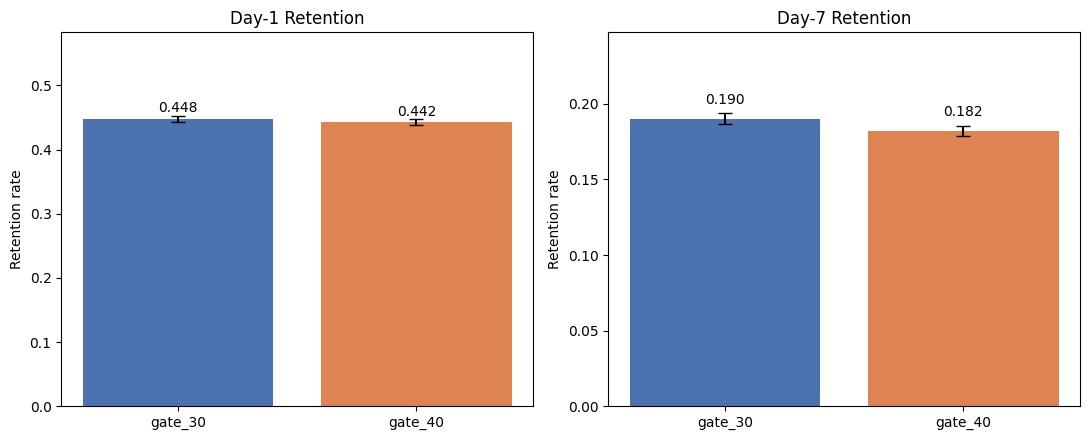

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, col, title in zip(axes, ['retention_1','retention_7'], ['Day-1 Retention','Day-7 Retention']):
    means = df.groupby('version')[col].mean()
    ses = df.groupby('version')[col].apply(lambda x: np.sqrt(x.mean()*(1-x.mean())/len(x)))
    bars = ax.bar(means.index, means.values, yerr=1.96*ses.values, capsize=5, color=['#4C72B0','#DD8452'])
    ax.set_title(title); ax.set_ylabel('Retention rate'); ax.set_ylim(0, max(means.values)*1.3)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}', ha='center')
plt.tight_layout()
plt.show()

Result: retention_1 drops slightly (-0.59pp, p=0.074, not significant at α=0.05) and retention_7 drops significantly (-0.82pp, p=0.0016) when the gate moves to level 40. Both point estimates are negative, i.e. moving the gate later **hurt** retention rather than helping it.

## 4. Bootstrap Cross-Check

A non-parametric cross-check on the z-test results, to confirm the normal approximation is reasonable here.

In [6]:
np.random.seed(42)

def bootstrap_diff(col, n_boot=10000):
    g30 = df[df.version=='gate_30'][col].values.astype(float)
    g40 = df[df.version=='gate_40'][col].values.astype(float)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        s30 = np.random.choice(g30, size=len(g30), replace=True)
        s40 = np.random.choice(g40, size=len(g40), replace=True)
        diffs[i] = s40.mean() - s30.mean()
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    p_boot = 2*min((diffs>0).mean(), (diffs<0).mean())
    print(f"{col}: bootstrap mean diff={diffs.mean()*100:.3f} pp, 95% CI [{ci_low*100:.3f}, {ci_high*100:.3f}] pp, p~{p_boot:.4f}")

bootstrap_diff('retention_1')
bootstrap_diff('retention_7')

retention_1: bootstrap mean diff=-0.590 pp, 95% CI [-1.237, 0.059] pp, p~0.0772


retention_7: bootstrap mean diff=-0.818 pp, 95% CI [-1.329, -0.312] pp, p~0.0026


Bootstrap results match the analytic z-test closely, confirming the normal approximation holds fine at this sample size.

## 5. Outlier Robustness Check

`sum_gamerounds` has one extreme outlier (49,854 rounds in 14 days, almost certainly a bot or logging error). Since `retention_1` and `retention_7` are binary, a single row can't really shift a proportion test, but it's worth confirming explicitly.

In [7]:
print(df[df.sum_gamerounds > 10000])

df_clean = df[df.sum_gamerounds <= 10000]
print(f"\nRows removed: {len(df) - len(df_clean)}\n")

for col in ['retention_1', 'retention_7']:
    g30 = df_clean[df_clean.version=='gate_30'][col]
    g40 = df_clean[df_clean.version=='gate_40'][col]
    count = np.array([g40.sum(), g30.sum()]); nobs = np.array([len(g40), len(g30)])
    z, p = proportions_ztest(count, nobs)
    print(f"{col} (outlier removed): diff={(g40.mean()-g30.mean())*100:.3f} pp, p={p:.4f}")

        userid  version  sum_gamerounds  retention_1  retention_7
57702  6390605  gate_30           49854        False         True

Rows removed: 1

retention_1 (outlier removed): diff=-0.592 pp, p=0.0739
retention_7 (outlier removed): diff=-0.818 pp, p=0.0016


Removing the outlier doesn't change anything meaningful. Both effect sizes and p-values are essentially identical. The conclusions aren't being driven by this one data point.

## 6. Variance Reduction (CUPED)

CUPED (Controlled-experiment Using Pre-Experiment Data) reduces variance in the outcome by adjusting for a covariate correlated with it, tightening confidence intervals without affecting the unbiasedness of the estimate. This only works cleanly if the covariate is measured before treatment assignment, so it can't itself be affected by treatment.

Caveat worth stating upfront: this dataset doesn't have a genuine pre-treatment covariate. `sum_gamerounds` is measured over the same 14-day window as the outcomes, so it could itself be influenced by which gate a player saw. We check this directly below. The CUPED computation that follows is included to show how the technique works, but in a real production setting at a company like Whatnot, you'd want a covariate from before the experiment started, like a user's historical engagement, rather than this kind of contemporaneous measure.

In [8]:
# Check whether sum_gamerounds itself differs by treatment group
g30_rounds = df[df.version=='gate_30']['sum_gamerounds']
g40_rounds = df[df.version=='gate_40']['sum_gamerounds']
u, p_contam = stats.mannwhitneyu(g30_rounds, g40_rounds)
print(f"Is sum_gamerounds itself affected by treatment? Mann-Whitney p = {p_contam:.4f}")
print("(p < 0.05 here would mean the covariate fails CUPED's core pre-treatment assumption)")

Is sum_gamerounds itself affected by treatment? Mann-Whitney p = 0.0502
(p < 0.05 here would mean the covariate fails CUPED's core pre-treatment assumption)


In [9]:
df['retention_7_int'] = df['retention_7'].astype(int)
X = df['sum_gamerounds'].values
Y = df['retention_7_int'].values

theta = np.cov(X, Y)[0,1] / np.var(X)
Y_cuped = Y - theta * (X - X.mean())
df['retention_7_cuped'] = Y_cuped

g30c = df[df.version=='gate_30']['retention_7_cuped']
g40c = df[df.version=='gate_40']['retention_7_cuped']

t, p_cuped = stats.ttest_ind(g40c, g30c)
diff_cuped = g40c.mean() - g30c.mean()
se_cuped = np.sqrt(g30c.var(ddof=1)/len(g30c) + g40c.var(ddof=1)/len(g40c))

var_reduction = (1 - g30c.var()/g30_rounds.size**0) # placeholder, recompute below
var_raw = np.var(Y[df.version=='gate_30'])
var_adj = np.var(Y_cuped[df.version=='gate_30'])
var_reduction = (1 - var_adj/var_raw) * 100

print(f"theta = {theta:.6f}")
print(f"Raw diff = -0.820 pp (from section 3)")
print(f"CUPED-adjusted diff = {diff_cuped*100:.3f} pp, 95% CI [{(diff_cuped-1.96*se_cuped)*100:.3f}, {(diff_cuped+1.96*se_cuped)*100:.3f}] pp")
print(f"t = {t:.3f}, p = {p_cuped:.5f}")
print(f"Variance reduction: {var_reduction:.2f}%")

theta = 0.000557
Raw diff = -0.820 pp (from section 3)
CUPED-adjusted diff = -0.756 pp, 95% CI [-1.244, -0.268] pp
t = -3.036, p = 0.00239
Variance reduction: 2.34%


**Result:** CUPED gives a modest ~2% variance reduction here, small, because the available covariate is only moderately correlated with the outcome (r ≈ 0.28) and is itself borderline contaminated by treatment. The directional conclusion doesn't change: retention_7 is still significantly lower for gate_40. This is basically the expected outcome of an honest CUPED attempt on a dataset that lacks true pre-period data, and it's worth saying plainly rather than dressing it up.

## 7. Summary & Recommendation

Overall Observation:
- Moving the first gate from level 30 to level 40 decreased retention in both windows.
- Day-1 retention: 44.8% to 44.2% (-0.59pp), not statistically significant (p=0.074). The experiment was slightly underpowered to detect an effect this size at 80% power.
- Day-7 retention: 19.0% to 18.2% (-0.82pp), statistically significant (p=0.0016), confirmed by bootstrap and robust to the single extreme outlier in the data.
- The Sample Ratio Mismatch check flagged a small (0.9pp) group-size imbalance, worth a closer look in a live setting, though unlikely to explain the retention effects given their direction and size.
- CUPED variance reduction was minimal because this dataset lacks a genuine pre-treatment covariate. That's a real limitation of the data, not a failure of the technique.

Recommendation: don't move the gate to level 40. The data suggests the earlier gate at level 30 might act as a helpful early commitment or pacing mechanic rather than friction. Delaying it gave players less reason to come back a week later.

Maybe in the future: a finer sweep of gate placements (30, 35, 40, 45) to map out where retention peaks, segmented by player skill or speed since `sum_gamerounds` correlates with retention, and if this were a live company test, genuine pre-period engagement data so CUPED variance reduction would actually mean something.